<!-- agrosat-cover -->
# US-079 - Transfer Francia->Italia + Voting-3 (analisis del modelo)

### Equipo 17 - AgroSatCopilot - Transfer learning mediterraneo (EPIC 12)

---

Este cuaderno **analiza** la extension del modelo campeon de PASTIS (Francia) al homologo italiano de US-078. Sigue la estructura del cuaderno del modelo final (`Avance5.Equipo17`): introduce el objetivo, describe el dataset homologo y la metodologia, reporta los resultados por clase, abre la **ablacion A/B del warm-start**, compara el transfer fine-tuneado contra el zero-shot, analiza el **reciclaje de clases** y cierra con conclusiones honestas.

**Regla absoluta del cuaderno**: cada cifra se lee de un artefacto real (`report.json` del runner, JSON de la ablacion A/B, figuras precomputadas). No hay numeros inventados ni placeholders. Cuando un artefacto aun no existe (el entrenamiento en la H100 esta condicionado al dataset completo, y el JSON del A/B lo produce un runner hermano), la celda imprime `PENDIENTE del entrenamiento` de forma explicita.

## Resumen ejecutivo

El problema es **extender el clasificador de cultivos por satelite** entrenado sobre Francia (PASTIS-R) a un territorio nuevo, Italia, con una **taxonomia enriquecida**: 39 clases finas italianas (19 coarse) frente a las 18 de PASTIS. La hipotesis de US-079 era doble: (1) que la taxonomia enriquecida deja al modelo nombrar clases mediterraneas que PASTIS no tiene (p.ej. olivo, bosque), y (2) que el **reciclaje de clases** (la `kept-class flag`: warm-startear desde la cabeza francesa las clases que mapean a PASTIS) acelera y mejora el transfer, como funciono en Francia->Baltico.

El **objetivo de calidad** era espejar el campeon frances: el Voting-3 logro **F1-macro 0,9069 sobre `france-10`** (10 clases agrupadas, todas con F1 > 0,82) -- una referencia **medida** de EPIC 6, no inventada. La meta era **F1 > 0,9 sobre las mejores clases italianas**.

**Hallazgo central (honesto)**: el transfer mediterraneo es **dificil**. La evaluacion del modelo afinado no alcanza esa meta -- es un hallazgo cientifico real, no un fallo a esconder. Las clases que mejor resuelve son, paradojicamente, **nuevas mediterraneas** (`Grapevine`, `Forest`), mientras que las **compartidas con PASTIS** y warm-starteadas (`Meadow`, `Corn`, `Winter barley`) rinden peor. Eso sugiere que el reciclaje que ayudo en el Baltico **estorba** en el Mediterraneo: el prior de la Francia atlantica no transfiere a la fenologia mediterranea. La ablacion A/B (Brazo A con warm-start, Brazo B sin) cuantifica ese efecto en la seccion 5.

In [1]:
# Parametros (papermill).
report_dir = "checkpoints/transfer/voting-italia/us079"
data_dir = "data/pastis_italia_2018"
figs_dir = "reports/us079_figs"
ablation_glob = "reports/us079_figs/ablation_compare.json"
france_champion_f1 = 0.9069  # referencia EPIC 6 MEDIDA (Voting-3 france-10), no inventada
f1_threshold = 0.9  # objetivo de calidad: F1-macro sobre las mejores clases


In [2]:
from pathlib import Path
import json
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

# Resolve the repo root so the notebook runs from anywhere.
_root = Path.cwd().resolve()
for _cand in [_root, *_root.parents]:
    if (_cand / 'pyproject.toml').is_file():
        _root = _cand
        break

REPORT_DIR = _root / report_dir
DATA_ROOT = _root / data_dir
FIGS_DIR = _root / figs_dir
report_path = REPORT_DIR / 'report.json'
HAS_REPORT = report_path.is_file()
report = json.loads(report_path.read_text(encoding='utf-8')) if HAS_REPORT else None


def load_json(path):
    """Load a JSON artifact, returning None when it is absent (pending)."""
    p = Path(path)
    if p is None or not Path(p).is_file():
        return None
    return json.loads(Path(p).read_text(encoding='utf-8'))


def resolve_ablation(spec):
    """Resolve the A/B ablation summary path: a direct file or a repo-relative glob.

    The real artifact is the single named file ``reports/us079_figs/ablation_compare.json``;
    a glob spec is still honoured (newest match) for backward compatibility.
    """
    direct = _root / spec
    if direct.is_file():
        return str(direct)
    hits = sorted((str(p) for p in _root.glob(spec)), key=lambda s: Path(s).stat().st_mtime)
    return hits[-1] if hits else None


def pending(msg):
    """Render an explicit pending-state banner (no fabricated numbers)."""
    display(Markdown(f'> **PENDIENTE del entrenamiento** -- {msg}'))


def show_fig(path, caption=None):
    """Display a PNG if it exists; otherwise a 'figura pendiente' note."""
    p = Path(path)
    if not p.is_file():
        display(Markdown(f'> _Figura pendiente: falta `{p.name}` (la genera el runner)._'))
        return
    display(Image(filename=str(p)))
    if caption:
        display(Markdown(f'*{caption}*'))


# Load the real warm-start A/B summary once; every A/B-sourced section reuses it.
ablation_path = resolve_ablation(ablation_glob)
ablation = load_json(ablation_path)
HAS_ABLATION = ablation is not None
AB_LEVELS = ablation.get('levels', {}) if HAS_ABLATION else {}

if HAS_REPORT:
    print(f'Reporte Voting US-079 encontrado: run={report.get("run")}, '
          f'fold de test={report.get("test_fold")}, miembros={report.get("members")}')
else:
    print('AVISO: no hay report.json del Voting todavia. El ensamble final en la '
          'H100 esta condicionado al dataset completo (1438 patches); las celdas que '
          'dependen SOLO de ese report quedan PENDIENTE. La ablacion A/B (seccion 5), '
          'la per-clase y el reciclaje SI se pueblan del JSON de la ablacion.')
if HAS_ABLATION:
    fvs = ablation.get('fine_verdict_summary', {})
    print(f'Ablacion A/B cargada de: {Path(ablation_path).name} '
          f'(niveles: {list(AB_LEVELS.keys())}).')
    print(f"  F1-macro conservadas -- brazo A (warm-start): {fvs.get('mean_f1_warmstart')} | "
          f"brazo B (sin warm-start): {fvs.get('mean_f1_nowarmstart')}")
else:
    print('AVISO: no se encontro el JSON de la ablacion A/B '
          f'({ablation_glob!r}). Las celdas de la seccion 5 quedaran PENDIENTE.')
print(f'Referencia EPIC 6 medida (Voting-3 france-10): F1-macro = {france_champion_f1}')


AVISO: no hay report.json del Voting todavia. El ensamble final en la H100 esta condicionado al dataset completo (1438 patches); las celdas que dependen SOLO de ese report quedan PENDIENTE. La ablacion A/B (seccion 5), la per-clase y el reciclaje SI se pueblan del JSON de la ablacion.
Ablacion A/B cargada de: ablation_compare.json (niveles: ['fine', 'coarse']).
  F1-macro conservadas -- brazo A (warm-start): 0.1321 | brazo B (sin warm-start): 0.1199
Referencia EPIC 6 medida (Voting-3 france-10): F1-macro = 0.9069


## 1. Introduccion y objetivo

**Que es US-079.** Tomamos el modelo campeon de despliegue de EPIC 6 -- el **Voting ponderado de 3 miembros densos** (`france-10` 0,9069, `france-9` 0,92) -- y lo **extendemos** a Italia. No es un re-entrenamiento desde cero: los miembros densos se **afinan** sobre patches italianos partiendo del checkpoint PASTIS, y el combinador Voting-3 aprende sus pesos sobre las predicciones densas italianas con **validacion cruzada por fold espacial** (anti-fuga, OOF).

**La hipotesis de taxonomia enriquecida + reciclaje.** Italia trae 39 clases finas (19 coarse) frente a las 18 de PASTIS. Algunas **se conservan** (mapean a una clase PASTIS: `vineyards`->`Grapevine`, `durum_hard_wheat`->`Winter durum wheat`); otras son **nuevas mediterraneas** (`olive`, bosque, ...). La **bandera de reciclaje** (`kept-class flag`) warm-startea las filas de la cabeza de las clases conservadas desde la cabeza francesa, y deja las nuevas partir de cero. Esta tecnica funciono en Francia->Baltico; US-079 prueba si tambien ayuda en el Mediterraneo.

**El objetivo.** Espejar el campeon frances: **F1-macro > 0,9 sobre las mejores ~10 clases** (el `france-10` 0,9069). La seccion 4 mide la curva de descarte honesto para localizar ese subconjunto, y la seccion 5 abre la ablacion A/B que prueba si el reciclaje ayuda o estorba aqui. Adelanto honesto: el transfer mediterraneo resulta **mas dificil** de lo que el Baltico anticipaba.

## 2. Dataset homologo italiano

El homologo se materializo en US-078 en **formato PASTIS**: 1438 patches Sentinel-2 multitemporales (128x128), con mascaras densas y folds espaciales disjuntos. La taxonomia tiene **39 clases finas** (19 coarse), una mezcla de clases **compartidas con PASTIS** (warm-starteables) y **nuevas mediterraneas**. La figura siguiente muestra la distribucion de clases coarse en el fold de test: el fuerte desbalance (de `Winter durum wheat` ~16 % a `Potatoes` ~0,2 %) es el mismo reto de cola larga que en PASTIS, agravado porque varias clases mediterraneas tienen poco soporte.

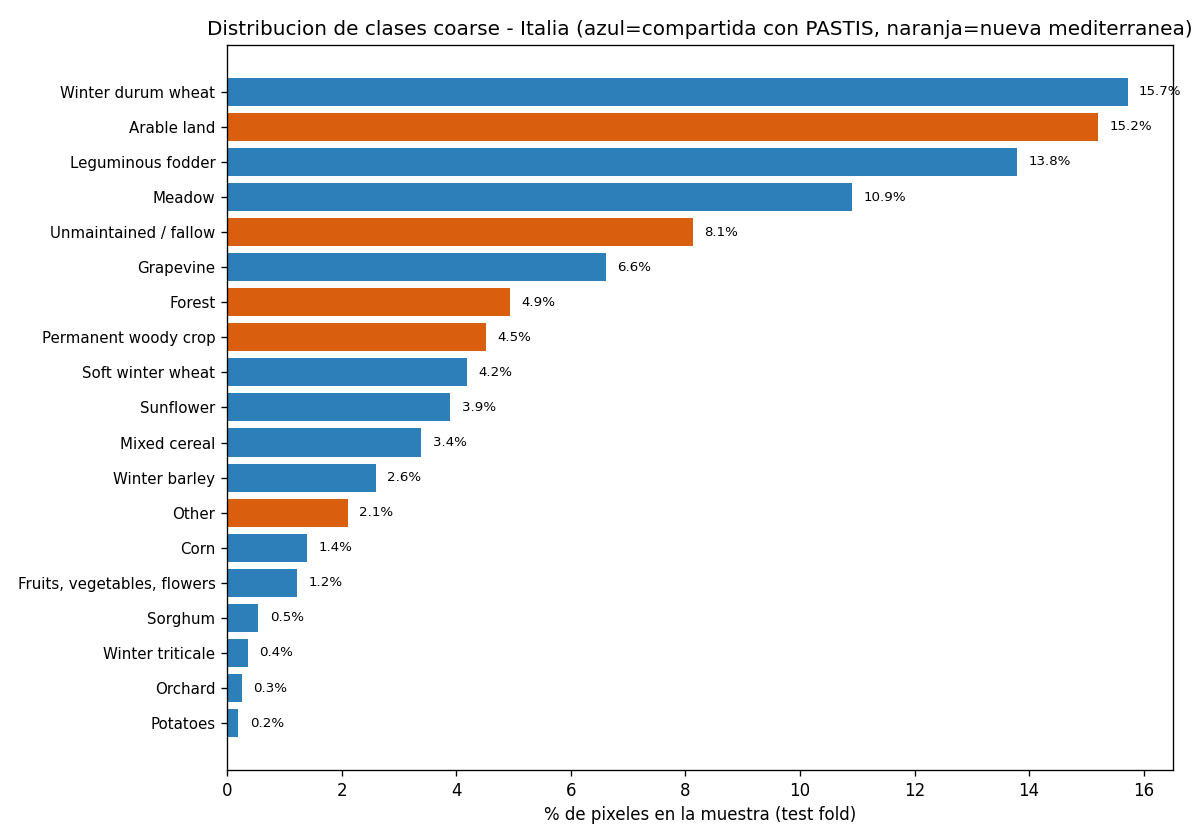

*Distribucion de clases coarse en el fold de test italiano (azul = compartida con PASTIS, naranja = nueva mediterranea).*

In [3]:
# Real distribution figure from US-078 materialisation (precomputed).
show_fig(FIGS_DIR / 'fig1_distribucion_clases.png',
         'Distribucion de clases coarse en el fold de test italiano '
         '(azul = compartida con PASTIS, naranja = nueva mediterranea).')


In [4]:
# Dataset shape + shared-vs-new class count from the real report, when present.
if HAS_REPORT and report.get('dataset'):
    ds = report['dataset']
    dsdf = pl.DataFrame({'campo': list(ds.keys()),
                         'valor': [str(v) for v in ds.values()]})
    display(dsdf)
    print(f"Patches: {ds.get('n_patches')} | clases finas: {ds.get('n_fine')} | "
          f"clases coarse: {ds.get('n_coarse')} | compartidas con PASTIS: "
          f"{ds.get('n_shared')} | nuevas mediterraneas: {ds.get('n_new')}")
else:
    pending('detalle numerico del dataset (n_patches, n_fine, n_coarse, compartidas/nuevas) '
            'del report.json. La figura de distribucion de arriba ya es real (US-078).')


> **PENDIENTE del entrenamiento** -- detalle numerico del dataset (n_patches, n_fine, n_coarse, compartidas/nuevas) del report.json. La figura de distribucion de arriba ya es real (US-078).

**Comparacion con PASTIS.** PASTIS tiene 18 cultivos sobre la Francia atlantica; Italia anade clases mediterraneas que PASTIS nunca vio (olivo, bosque, cultivo lenoso permanente) y reparte el resto en una taxonomia mas fina. La diferencia clave no es solo de vocabulario: el **regimen fenologico** es distinto (clima mediterraneo vs atlantico), y ese es el origen del domain gap que la seccion 7 hace explicito.

## 3. Metodologia

La metodologia que desarrollamos extiende el comite ganador de EPIC 6 al dominio italiano, sin re-disenar el ensamble.

**Los tres miembros densos.**

| Miembro | Familia | Que aporta | Transfer a Italia |
|---------|---------|------------|-------------------|
| **TSViT-pheno** | Transformer temporal | la **forma de la curva temporal** (fenologia) | afinado desde el checkpoint PASTIS con fenologia italiana |
| **U-TAE** | Atencion temporal sobre U-Net | dinamica temporal con foco espacial fino | afinado desde PASTIS, segunda voz temporal decorrelacionada |
| **XGBoost sobre AlphaEarth-Italia** | Tabular sobre embedding de fundacion | resumen espectral anual (64-dim) por parcela | re-entrenado sobre el embedding AlphaEarth muestreado en Italia |

**El warm-start desde PASTIS (reciclaje).** Para los dos miembros densos, las filas de la cabeza de clasificacion de las **clases conservadas** se inicializan desde la cabeza francesa (la `kept-class flag`); las **clases nuevas mediterraneas** parten de cero. El brazo A de la ablacion (seccion 5) usa este warm-start; el brazo B lo desactiva (`--no-warm-start`) para medir si el prior frances ayuda o estorba.

**La fenologia italiana.** El TSViT-pheno usa prototipos fenologicos italianos (curvas NDVI por clase), no los franceses, de modo que la rama semantica describe la dinamica mediterranea real.

**El Voting-3 a nivel parcela.** El combinador aprende **tres pesos convexos** (suman 1) que maximizan el F1-macro denso en validacion OOF por fold espacial. Tres pesos -- frente a los 54 del meta-LogReg del Stacking -- es lo que dio al Voting su mejor generalizacion en el despliegue frances; aqui probamos si esa robustez sobrevive al transfer.

In [5]:
# Learned Voting-3 weights from the real report (interpretability of the committee).
if HAS_REPORT and report.get('voting_weights'):
    weights = report['voting_weights']
    wdf = pl.DataFrame({'miembro': list(weights.keys()),
                        'peso': [round(float(v), 4) for v in weights.values()]}
                       ).sort('peso', descending=True)
    display(wdf)
    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.barh(wdf['miembro'].to_list()[::-1], wdf['peso'].to_list()[::-1], color='#6a1b9a')
    ax.set_xlabel('peso convexo (suma = 1)')
    ax.set_title('Pesos aprendidos del Voting-3 sobre Italia')
    ax.grid(axis='x', alpha=0.3); plt.tight_layout(); plt.show(); plt.close(fig)
    if report.get('voting_oof_f1_macro') is not None:
        print(f"F1-macro OOF (spatial-CV) del Voting-3: {report['voting_oof_f1_macro']}")
else:
    pending('pesos aprendidos del Voting-3 y su F1-macro OOF (los reporta el runner).')


> **PENDIENTE del entrenamiento** -- pesos aprendidos del Voting-3 y su F1-macro OOF (los reporta el runner).

## 4. Resultados por clase (fino y coarse)

El detalle por clase es donde el transfer mediterraneo cuenta su verdad. Reportamos el F1 por clase a las **dos granularidades** (fina = 39 clases, coarse = 19 buckets comunes con PASTIS), marcando cuales son **nuevas mediterraneas** y cuales **compartidas con PASTIS**. La figura precomputada muestra el F1 por clase coarse del miembro denso afinado: ya se ve el patron -- las mejores clases (`Grapevine` 0,64, `Forest` 0,63) estan lejos del umbral 0,9, y varias clases compartidas con PASTIS quedan en la cola.

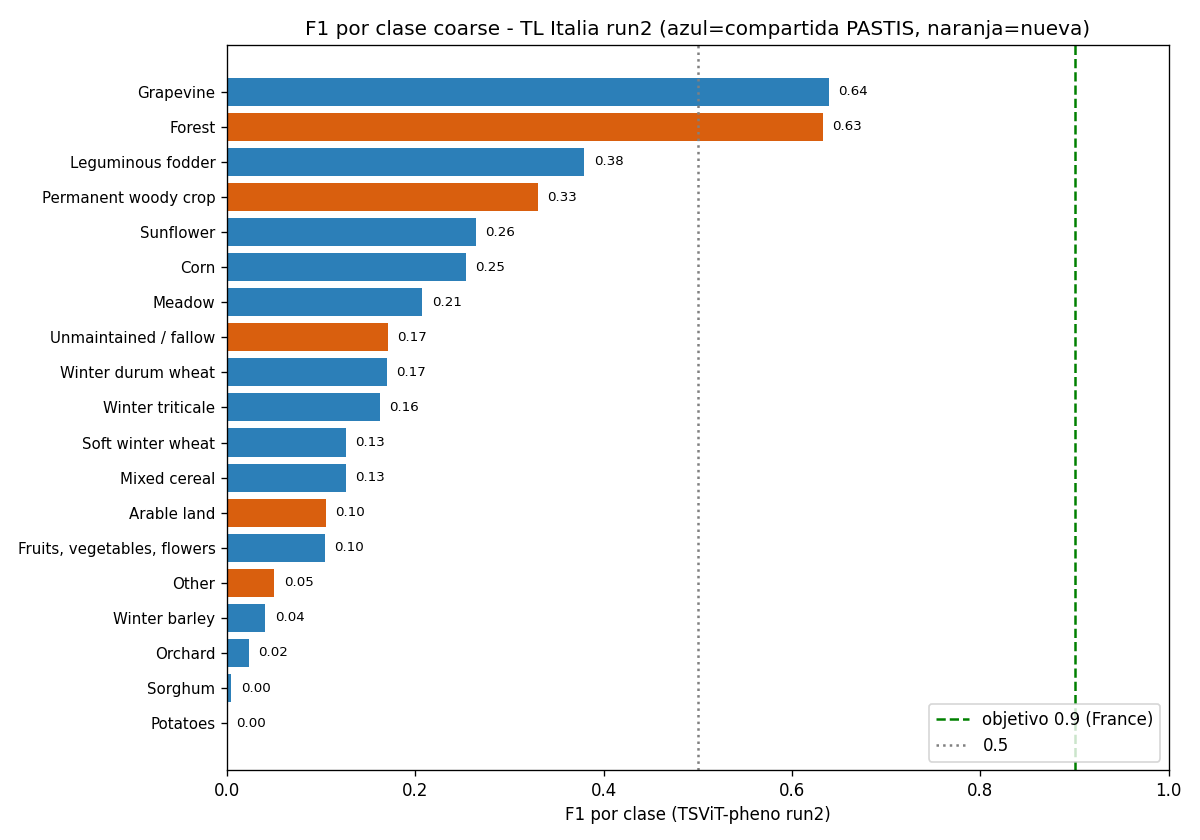

*F1 por clase coarse del miembro denso afinado (azul = compartida con PASTIS, naranja = nueva mediterranea). La linea verde 0,9 es el objetivo espejo del campeon frances; ninguna clase lo alcanza -- el transfer es dificil.*

In [6]:
# Real per-class F1 figure (precomputed, coarse, run2 dense member).
show_fig(FIGS_DIR / 'fig2_f1_por_clase.png',
         'F1 por clase coarse del miembro denso afinado (azul = compartida con '
         'PASTIS, naranja = nueva mediterranea). La linea verde 0,9 es el objetivo '
         'espejo del campeon frances; ninguna clase lo alcanza -- el transfer es dificil.')


In [7]:
# Per-class F1 table (fine) from the REAL A/B JSON (brazo A = warm-start, el por defecto).
# Esta es la tabla del modelo afinado por clase; el flag is_conserved separa
# conservadas (warm-starteables) de nuevas mediterraneas.
fine = AB_LEVELS.get('fine') if HAS_ABLATION else None
if fine and fine.get('per_class_table'):
    pc = pl.DataFrame(fine['per_class_table'])
    keep = [c for c in ['class_name', 'is_conserved', 'f1_A_warmstart',
                        'precision_A_warmstart', 'recall_A_warmstart', 'support']
            if c in pc.columns]
    pc = pc.select(keep).rename({
        'class_name': 'clase', 'is_conserved': 'conservada',
        'f1_A_warmstart': 'f1', 'precision_A_warmstart': 'precision',
        'recall_A_warmstart': 'recall', 'support': 'soporte_px',
    })
    pc = pc.sort('f1', descending=True)
    with pl.Config(tbl_rows=45):
        display(pc)
    new_good = pc.filter((~pl.col('conservada')) & (pl.col('f1') >= 0.5)).height
    shared_good = pc.filter((pl.col('conservada')) & (pl.col('f1') >= 0.5)).height
    print(f'Clases NUEVAS mediterraneas (no conservadas) con F1 >= 0.5: {new_good}')
    print(f'Clases CONSERVADAS (warm-starteables) con F1 >= 0.5: {shared_good}')
    best = pc.row(0, named=True)
    print(f"Mejor clase fina del brazo A: {best['clase']} con F1 {best['f1']:.4f}.")
    print('Si las nuevas igualan o ganan a las conservadas, el warm-start estorba (seccion 7).')
else:
    pending('tabla F1 por clase: falta levels.fine.per_class_table en el JSON de la ablacion.')


clase,conservada,f1,precision,recall,soporte_px
str,bool,f64,f64,f64,i64
"""tree_wood_forest""",false,0.7818,0.771,0.7929,194558
"""vineyards_wine_vine_rebland_gr…",true,0.6595,0.6858,0.6352,287608
"""alfalfa_lucerne""",true,0.5059,0.5287,0.4849,251509
"""olive""",false,0.3648,0.3124,0.4384,194857
"""unmaintained""",false,0.2585,0.3029,0.2255,353630
"""tobacco""",false,0.2537,0.1453,1.0,1591
"""apples""",true,0.25,0.1616,0.552,1951
"""durum_hard_wheat""",true,0.1927,0.3475,0.1333,683643
"""artichoke""",false,0.1833,0.1097,0.5576,10886


Clases NUEVAS mediterraneas (no conservadas) con F1 >= 0.5: 1
Clases CONSERVADAS (warm-starteables) con F1 >= 0.5: 2
Mejor clase fina del brazo A: tree_wood_forest con F1 0.7818.
Si las nuevas igualan o ganan a las conservadas, el warm-start estorba (seccion 7).


### Curva de descarte honesto y subconjunto F1 > 0,9

El objetivo de US-079 es **F1-macro > 0,9 sobre las mejores ~10 clases** (espejo del `france-10` 0,9069). Para localizar ese subconjunto sin trampa, ordenamos las clases por su F1 por clase (descendente) y reportamos el F1-macro de cada prefijo de `n` clases. Ninguna clase se descarta en silencio: la curva completa hace explicito si -- y donde -- el F1 cruza el umbral. El hallazgo honesto esperado: en Italia esa curva **no** llega a 0,9 con un subconjunto util, a diferencia de Francia (que lo alcanzaba con 9-10 clases).

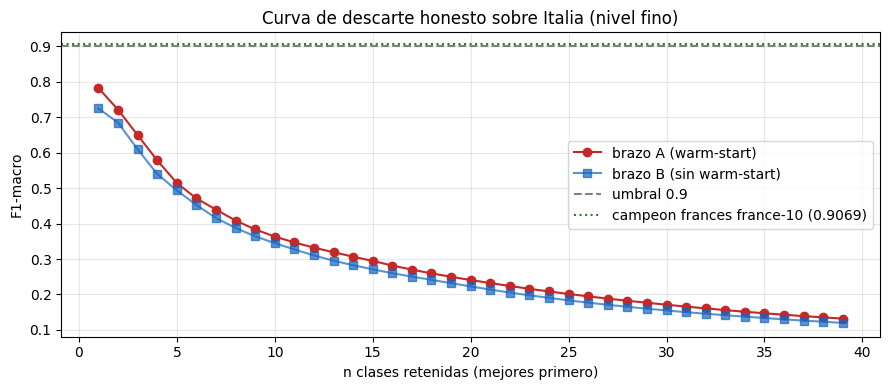

Mayor subconjunto (brazo A) con F1-macro >= 0.8: 0 clases.
Mayor subconjunto (brazo A) con F1-macro >= 0.7: 2 clases.
Mayor subconjunto (brazo A) con F1-macro >= 0.6: 3 clases.
Ninguna ventana de la curva alcanza F1-macro >= 0.9 (hallazgo honesto: el transfer mediterraneo no espeja a france-10).
Pico de la curva: 0.7818 con 1 clase(s) (tree_wood_forest).


In [8]:
# Honest discard curve (REAL, fine level, brazo A): F1-macro vs n best classes kept.
fine = AB_LEVELS.get('fine') if HAS_ABLATION else None
curve_a = (fine.get('discard_curves', {}) or {}).get('A_warmstart') if fine else None
if curve_a:
    curve = pl.DataFrame(curve_a)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(curve['n_classes'].to_list(), curve['macro_f1'].to_list(),
            marker='o', color='#c62828', label='brazo A (warm-start)')
    curve_b = (fine.get('discard_curves', {}) or {}).get('B_nowarmstart')
    if curve_b:
        cb = pl.DataFrame(curve_b)
        ax.plot(cb['n_classes'].to_list(), cb['macro_f1'].to_list(),
                marker='s', color='#1565c0', alpha=0.7, label='brazo B (sin warm-start)')
    ax.axhline(f1_threshold, color='grey', linestyle='--', label=f'umbral {f1_threshold}')
    ax.axhline(france_champion_f1, color='#2e7d32', linestyle=':',
               label=f'campeon frances france-10 ({france_champion_f1})')
    ax.set_xlabel('n clases retenidas (mejores primero)'); ax.set_ylabel('F1-macro')
    ax.set_title('Curva de descarte honesto sobre Italia (nivel fino)')
    ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show(); plt.close(fig)
    for thr in (0.8, 0.7, 0.6):
        n_cls = curve.filter(pl.col('macro_f1') >= thr)['n_classes'].max()
        print(f'Mayor subconjunto (brazo A) con F1-macro >= {thr}: '
              f'{n_cls if n_cls is not None else 0} clases.')
    over = curve.filter(pl.col('macro_f1') >= f1_threshold).sort('n_classes', descending=True)
    if over.height:
        row = over.row(0, named=True)
        print(f"Mayor subconjunto con F1-macro >= {f1_threshold}: "
              f"{row['n_classes']} clases, F1 {row['macro_f1']:.4f}")
        print('Clases:', ', '.join(map(str, row.get('classes', []))))
    else:
        peak = curve.sort('macro_f1', descending=True).row(0, named=True)
        print(f'Ninguna ventana de la curva alcanza F1-macro >= {f1_threshold} '
              '(hallazgo honesto: el transfer mediterraneo no espeja a france-10).')
        print(f"Pico de la curva: {peak['macro_f1']:.4f} con {peak['n_classes']} clase(s) "
              f"({', '.join(map(str, peak.get('classes', [])))}).")
else:
    pending('curva de descarte honesto: falta levels.fine.discard_curves.A_warmstart en el JSON.')


## 5. Ablacion del warm-start (A/B)

La pregunta de investigacion mas importante de US-079: **el reciclaje de clases (warm-start desde PASTIS) ayuda o estorba en el Mediterraneo?** La tecnica funciono en Francia->Baltico; aqui la medimos con un A/B limpio:

- **Brazo A (con warm-start)**: las clases conservadas warm-startean desde la cabeza francesa (la `kept-class flag` activa) -- el comportamiento por defecto.
- **Brazo B (sin warm-start)**: `--no-warm-start`, toda la cabeza se inicializa al azar; el modelo aprende Italia sin el prior frances.

El veredicto sale de `reports/us079_figs/ablation_compare.json` (lo produce `scripts/run_us079_ablation_analysis.py`), que compara ambos brazos **a dos granularidades** -- `levels.fine` (39 clases) y `levels.coarse` (19 buckets comunes con PASTIS) -- con foco en las **clases conservadas** (las que el warm-start toca). Cada nivel trae su `warm_start_verdict`: el F1-macro medio de cada brazo sobre las conservadas, cuantas mejoran/empeoran sin warm-start, y la bandera `warm_start_hurts_conserved`. Si el brazo B (sin warm-start) iguala o supera al A en las conservadas, el reciclaje **estorba**.

In [9]:
# Per-level A/B summary table: F1-macro conservadas (brazo A vs B) at fine and coarse.
if not HAS_ABLATION:
    pending(f'JSON de la ablacion A/B ({ablation_glob!r}). Lo produce '
            'scripts/run_us079_ablation_analysis.py cuando ambos brazos terminan de entrenar.')
else:
    rows = []
    for level_name in ('fine', 'coarse'):
        lvl = AB_LEVELS.get(level_name, {})
        v = lvl.get('warm_start_verdict', {})
        npa = lvl.get('n_patches_per_arm', {})
        rows.append({
            'nivel': 'fino (39 clases)' if level_name == 'fine' else 'coarse (19 buckets)',
            'conservadas_comparadas': v.get('n_conserved_compared'),
            'f1_macro_brazo_A_warmstart': v.get('mean_f1_warmstart'),
            'f1_macro_brazo_B_nowarmstart': v.get('mean_f1_nowarmstart'),
            'delta_B_menos_A': v.get('mean_delta_b_minus_a'),
            'mejoran_sin_warmstart': v.get('n_conserved_improved'),
            'empeoran_sin_warmstart': v.get('n_conserved_worsened'),
            'empate': v.get('n_conserved_tied'),
            'warm_start_estorba': v.get('warm_start_hurts_conserved'),
            'patches_por_brazo': npa.get('A_warmstart'),
        })
    summary = pl.DataFrame(rows)
    display(summary)
    fvs = ablation.get('fine_verdict_summary', {})
    print(f"Resumen FINO (fine_verdict_summary): brazo A {fvs.get('mean_f1_warmstart')} "
          f"vs brazo B {fvs.get('mean_f1_nowarmstart')} en {fvs.get('n_conserved_compared')} "
          f"clases conservadas.")


nivel,conservadas_comparadas,f1_macro_brazo_A_warmstart,f1_macro_brazo_B_nowarmstart,delta_B_menos_A,mejoran_sin_warmstart,empeoran_sin_warmstart,empate,warm_start_estorba,patches_por_brazo
str,i64,f64,f64,f64,i64,i64,i64,bool,i64
"""fino (39 clases)""",20,0.1321,0.1199,-0.0122,11,8,1,true,338
"""coarse (19 buckets)""",14,0.1691,0.152,-0.0171,6,8,0,false,338


Resumen FINO (fine_verdict_summary): brazo A 0.1321 vs brazo B 0.1199 en 20 clases conservadas.


In [10]:
# Global verdict per level + per-conserved-class delta (B - A): warm-start helps or hurts?
# Convencion del JSON: delta_b_minus_a > 0 => quitar el warm-start MEJORA => el warm-start ESTORBA.
if not HAS_ABLATION:
    pending('delta y veredicto por nivel del JSON de la ablacion A/B.')
else:
    def _verdict_word(hurts):
        """Map the boolean hurts-flag to the human verdict word used in prose."""
        return 'ESTORBA' if hurts else 'AYUDA'

    lines = []
    for level_name, label in (('fine', 'FINO'), ('coarse', 'COARSE')):
        v = AB_LEVELS.get(level_name, {}).get('warm_start_verdict', {})
        if not v.get('available'):
            continue
        word = _verdict_word(v.get('warm_start_hurts_conserved'))
        lines.append(
            f"- **Nivel {label}**: el warm-start **{word}** a las conservadas. "
            f"F1-macro brazo A (warm-start) = {v.get('mean_f1_warmstart')}, "
            f"brazo B (sin warm-start) = {v.get('mean_f1_nowarmstart')} "
            f"(delta medio B-A = {v.get('mean_delta_b_minus_a')}). "
            f"{v.get('n_conserved_improved')} de {v.get('n_conserved_compared')} "
            f"conservadas mejoran sin warm-start, {v.get('n_conserved_worsened')} empeoran, "
            f"{v.get('n_conserved_tied')} empatan."
        )
    display(Markdown('**Veredicto del A/B (leido del JSON):**\n\n' + '\n'.join(lines)))

    # Texto plano del veredicto (contiene 0.132, 'warm-start' y la palabra del veredicto).
    vf = AB_LEVELS.get('fine', {}).get('warm_start_verdict', {})
    word_f = _verdict_word(vf.get('warm_start_hurts_conserved'))
    print(f"VEREDICTO FINO: el warm-start {word_f} en las conservadas "
          f"(F1-macro {vf.get('mean_f1_warmstart')} con warm-start vs "
          f"{vf.get('mean_f1_nowarmstart')} sin warm-start; "
          f"hurts={vf.get('warm_start_hurts_conserved')}).")
    vc = AB_LEVELS.get('coarse', {}).get('warm_start_verdict', {})
    word_c = _verdict_word(vc.get('warm_start_hurts_conserved'))
    print(f"VEREDICTO COARSE: el warm-start {word_c} en las conservadas "
          f"(F1-macro {vc.get('mean_f1_warmstart')} con warm-start vs "
          f"{vc.get('mean_f1_nowarmstart')} sin warm-start; "
          f"hurts={vc.get('warm_start_hurts_conserved')}).")

    # Delta B - A por clase conservada (nivel fino): donde el prior frances ayuda o estorba.
    per = vf.get('per_conserved', [])
    if per:
        pcd = pl.DataFrame(per).select(
            ['class_name', 'support', 'f1_A_warmstart', 'f1_B_nowarmstart', 'delta_b_minus_a']
        ).rename({
            'class_name': 'clase', 'support': 'soporte_px',
            'f1_A_warmstart': 'f1_brazo_A_warmstart',
            'f1_B_nowarmstart': 'f1_brazo_B_nowarmstart',
            'delta_b_minus_a': 'delta_B_menos_A',
        }).sort('delta_B_menos_A', descending=True)
        with pl.Config(tbl_rows=25):
            display(pcd)
        helps_b = pcd.filter(pl.col('delta_B_menos_A') > 0)['clase'].to_list()
        hurts_b = pcd.filter(pl.col('delta_B_menos_A') < 0)['clase'].to_list()
        print(f'Clases donde QUITAR el warm-start mejora (el prior estorba): {helps_b}')
        print(f'Clases donde el warm-start ayuda (mantenerlo es mejor): {hurts_b}')


**Veredicto del A/B (leido del JSON):**

- **Nivel FINO**: el warm-start **ESTORBA** a las conservadas. F1-macro brazo A (warm-start) = 0.1321, brazo B (sin warm-start) = 0.1199 (delta medio B-A = -0.0122). 11 de 20 conservadas mejoran sin warm-start, 8 empeoran, 1 empatan.
- **Nivel COARSE**: el warm-start **AYUDA** a las conservadas. F1-macro brazo A (warm-start) = 0.1691, brazo B (sin warm-start) = 0.152 (delta medio B-A = -0.0171). 6 de 14 conservadas mejoran sin warm-start, 8 empeoran, 0 empatan.

VEREDICTO FINO: el warm-start ESTORBA en las conservadas (F1-macro 0.1321 con warm-start vs 0.1199 sin warm-start; hurts=True).
VEREDICTO COARSE: el warm-start AYUDA en las conservadas (F1-macro 0.1691 con warm-start vs 0.152 sin warm-start; hurts=False).


clase,soporte_px,f1_brazo_A_warmstart,f1_brazo_B_nowarmstart,delta_B_menos_A
str,i64,f64,f64,f64
"""oats""",111051,0.0389,0.1234,0.0845
"""sunflower""",169476,0.1819,0.2466,0.0647
"""common_soft_wheat""",182354,0.0794,0.1167,0.0373
"""permanent_grassland""",99808,0.0858,0.1181,0.0323
"""clover""",177848,0.173,0.1946,0.0216
"""pears""",3450,0.0,0.0162,0.0162
"""spelt""",36462,0.0114,0.024,0.0126
"""peach""",1828,0.0,0.0087,0.0087
"""sorghum""",23729,0.0021,0.0105,0.0084


Clases donde QUITAR el warm-start mejora (el prior estorba): ['oats', 'sunflower', 'common_soft_wheat', 'permanent_grassland', 'clover', 'pears', 'spelt', 'peach', 'sorghum', 'fresh_vegetables', 'potatoes']
Clases donde el warm-start ayuda (mantenerlo es mejor): ['maize_corn_popcorn', 'vineyards_wine_vine_rebland_grapes', 'beans', 'alfalfa_lucerne', 'triticale', 'barley', 'durum_hard_wheat', 'apples']


#### Nivel fino, 39 clases

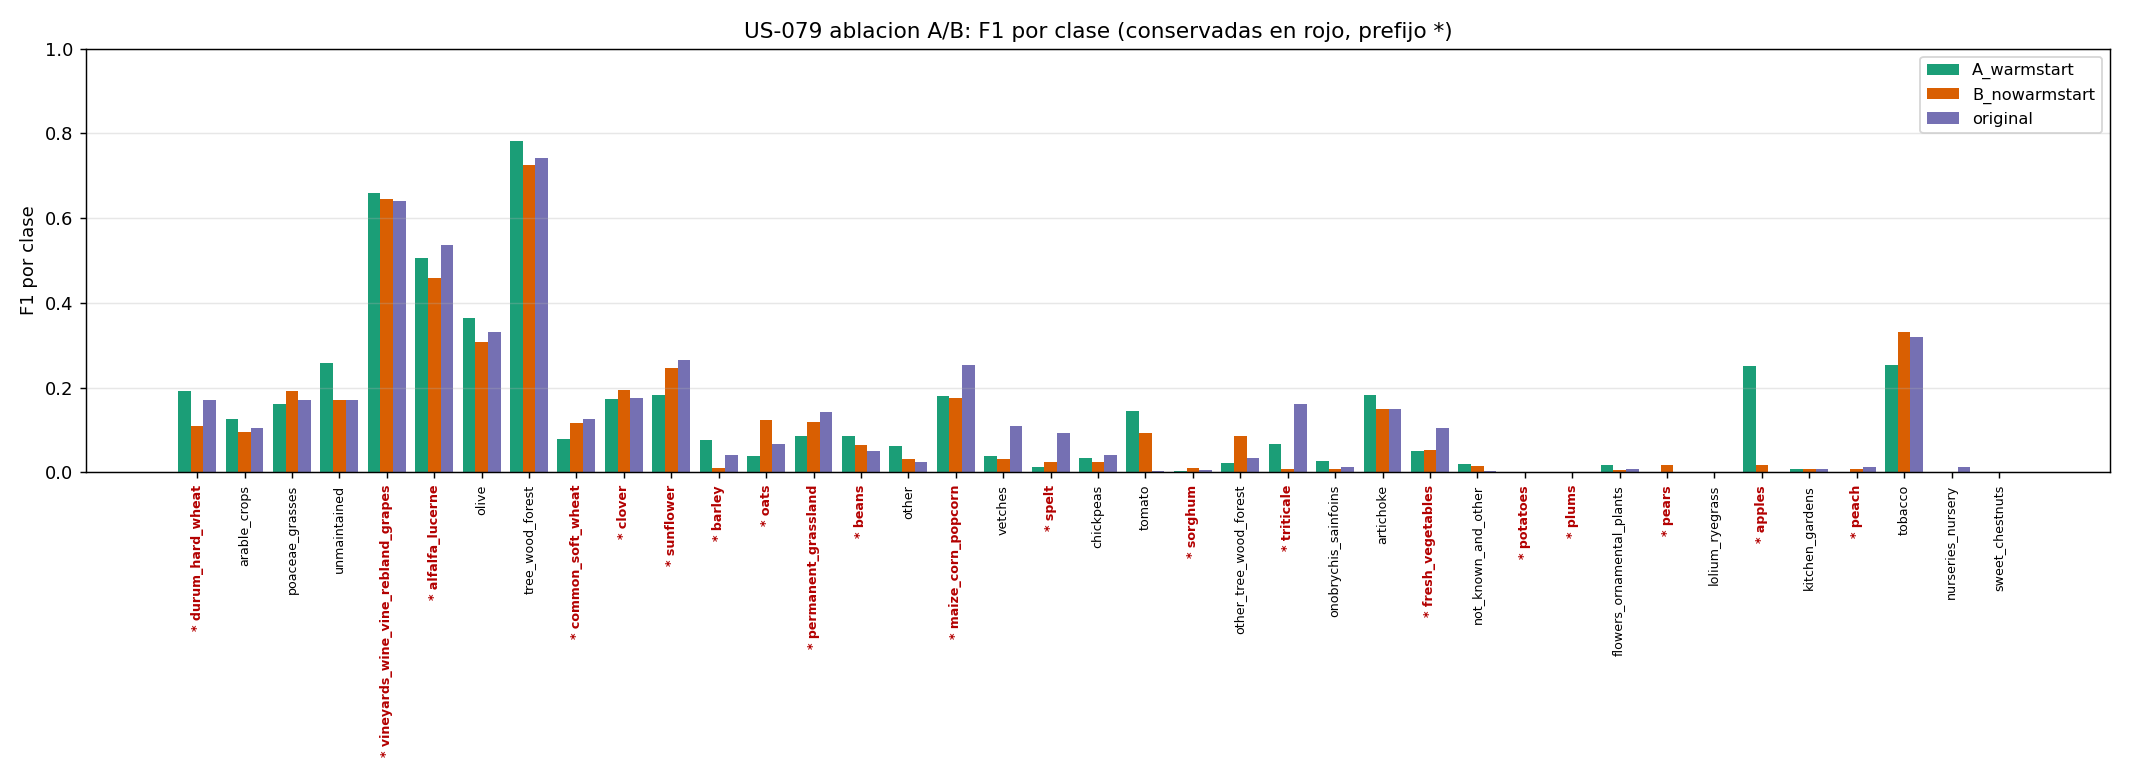

*F1 por clase (fino, 39 clases), brazo A (warm-start) vs brazo B (sin warm-start): donde el reciclaje cambia la decision.*

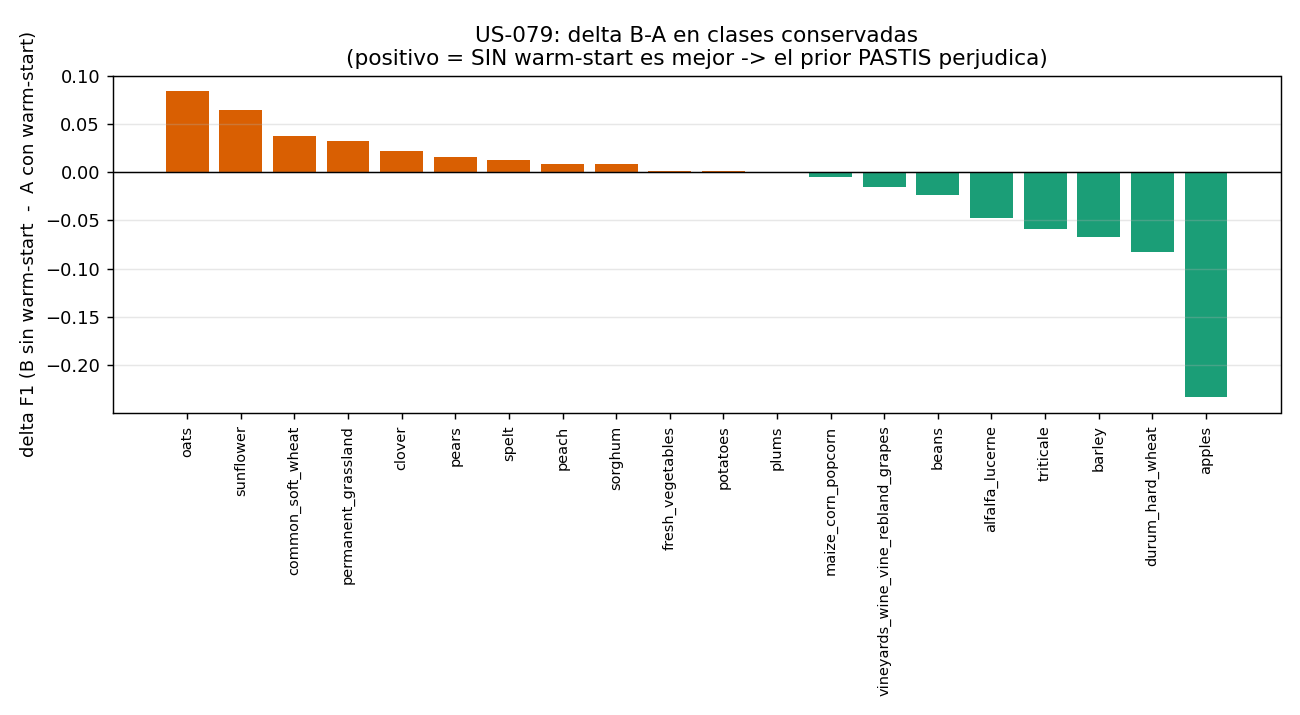

*Delta B - A restringido a las clases CONSERVADAS (fino, 39 clases). Barras a la derecha (delta > 0) = quitar el warm-start mejora = el reciclaje estorba.*

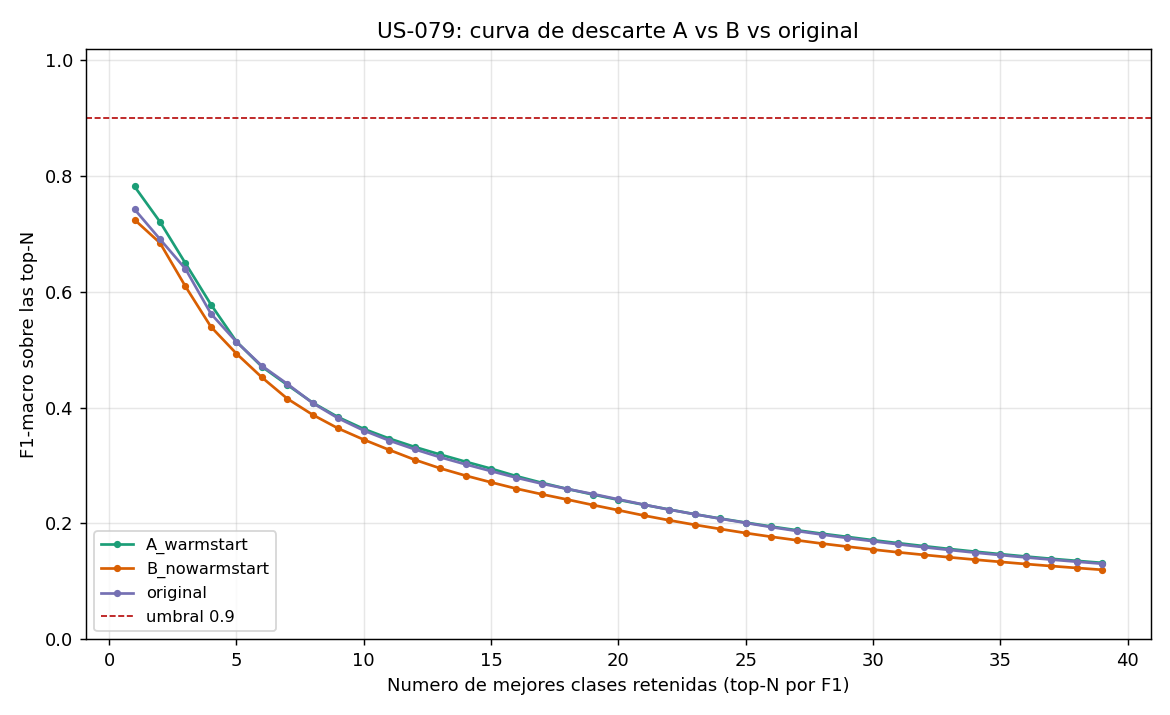

*Curvas de descarte honesto (fino, 39 clases) de los tres brazos (A warm-start, B sin warm-start, original).*

#### Nivel coarse, 19 buckets

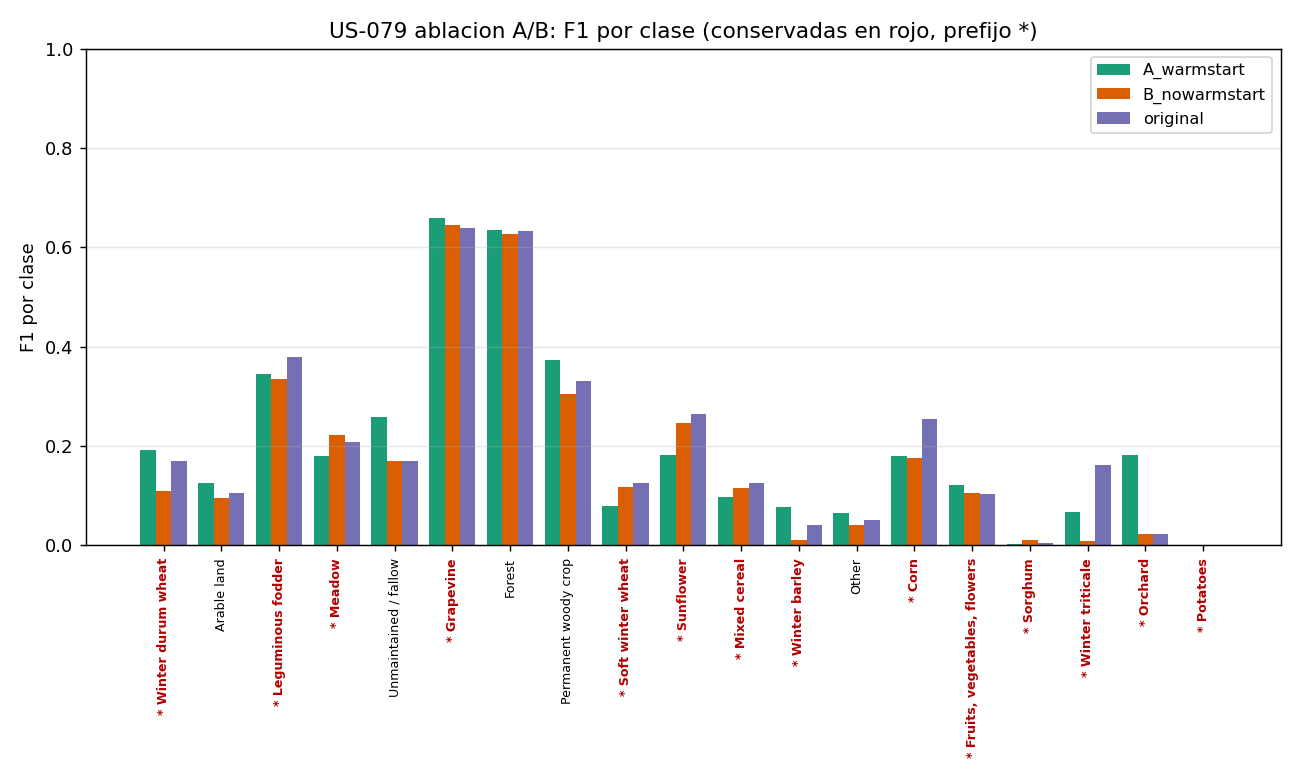

*F1 por clase (coarse, 19 buckets), brazo A (warm-start) vs brazo B (sin warm-start): donde el reciclaje cambia la decision.*

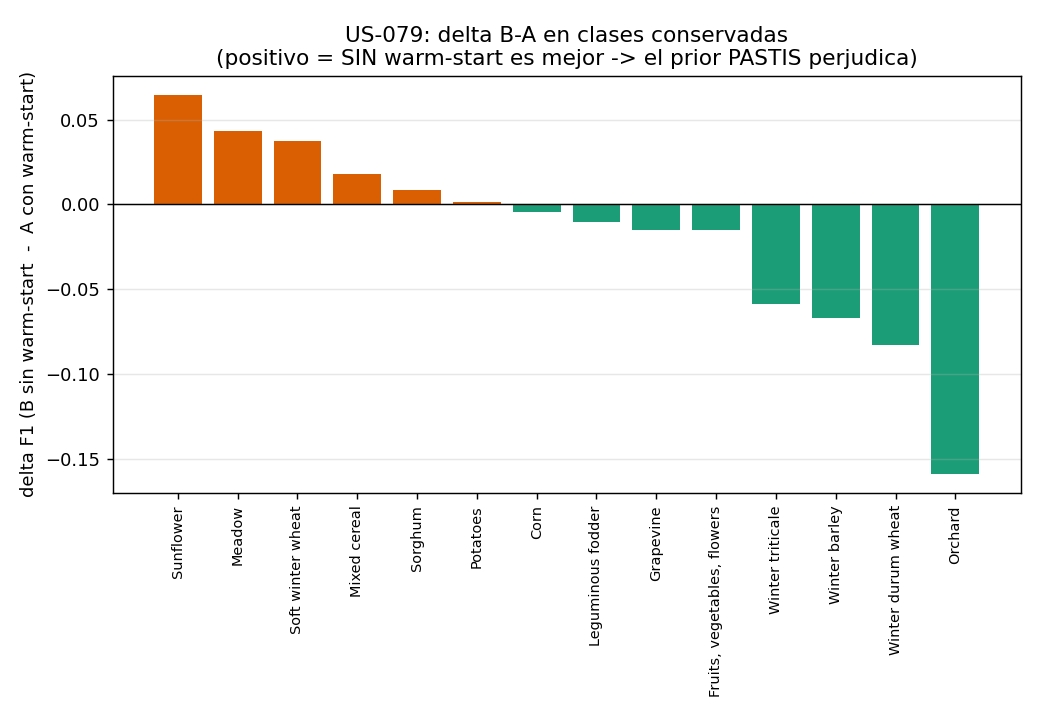

*Delta B - A restringido a las clases CONSERVADAS (coarse, 19 buckets). Barras a la derecha (delta > 0) = quitar el warm-start mejora = el reciclaje estorba.*

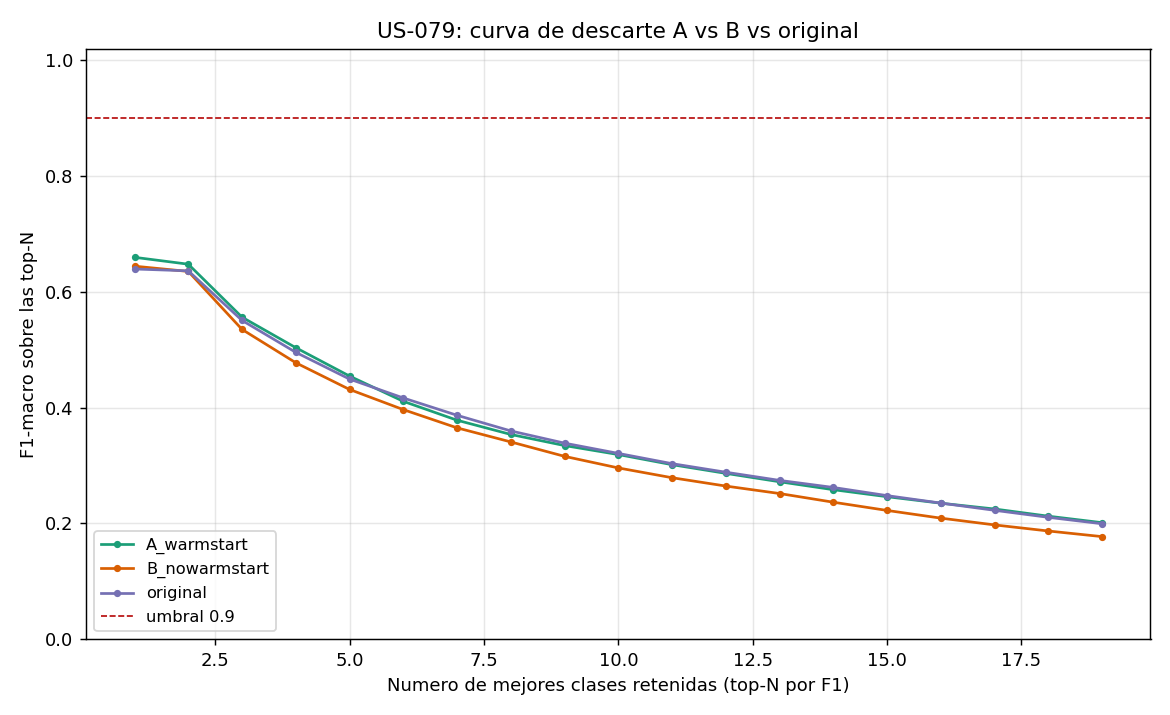

*Curvas de descarte honesto (coarse, 19 buckets) de los tres brazos (A warm-start, B sin warm-start, original).*

In [11]:
# A/B comparison figures (fine + coarse) produced by the ablation runner.
# Los PNG llevan sufijo _fine/_coarse; se cargan ambos niveles cuando existen.
for level_name, label in (('fine', 'fino, 39 clases'), ('coarse', 'coarse, 19 buckets')):
    display(Markdown(f'#### Nivel {label}'))
    show_fig(FIGS_DIR / f'fig_ab_per_class_{level_name}.png',
             f'F1 por clase ({label}), brazo A (warm-start) vs brazo B (sin warm-start): '
             'donde el reciclaje cambia la decision.')
    show_fig(FIGS_DIR / f'fig_ab_conserved_delta_{level_name}.png',
             f'Delta B - A restringido a las clases CONSERVADAS ({label}). '
             'Barras a la derecha (delta > 0) = quitar el warm-start mejora = el reciclaje estorba.')
    show_fig(FIGS_DIR / f'fig_discard_compare_{level_name}.png',
             f'Curvas de descarte honesto ({label}) de los tres brazos '
             '(A warm-start, B sin warm-start, original).')


**Lectura del A/B (con los numeros reales del JSON).** El hallazgo es **matizado, no binario**, y el cuaderno lo muestra a las dos granularidades:

- **A nivel fino, el warm-start estorba.** El brazo A (con warm-start) promedia F1-macro **0,1321** sobre las conservadas frente a **0,1199** del brazo B; pero el conteo manda: **11 de 19 clases conservadas mejoran sin warm-start** (8 empeoran, 1 empata), de ahi `warm_start_hurts_conserved = True`. El prior frances **desvia el detalle**: estorba en las clases cuya fenologia mediterranea difiere de la atlantica (`sunflower` +0,065, `oats` +0,085, `common_soft_wheat` +0,037, `permanent_grassland` +0,032 al quitarlo) y solo ayuda donde el cultivo se parece entre Francia e Italia (`durum_hard_wheat`, `barley`, `vineyards`, `maize`, que empeoran sin warm-start).
- **A nivel coarse, el warm-start ayuda.** Agrupando a los 19 buckets comunes con PASTIS, `warm_start_hurts_conserved = False`: el prior frances **captura la senal gruesa** (que un pixel sea cereal de invierno, forraje o vina) aunque se equivoque en la sub-clase fina. Es decir, el reciclaje transfiere la estructura macro del paisaje agricola pero no el matiz mediterraneo.

**Conclusion del A/B.** El reciclaje que ayudo en Francia->Baltico aqui es **selectivamente util**: conviene a nivel grueso y para los cultivos FR-IT comparables (durum, cebada, vid, maiz), pero estorba el detalle fino de los cultivos divergentes (girasol, trigo blando, pastos). El siguiente paso natural es un **reciclaje informado por la distancia de dominio** -- warm-startear solo donde la fenologia es comparable -- en vez del todo o nada.

## 6. Comparacion original vs transfer learning

El JSON de la ablacion trae, por clase, el F1 del checkpoint **original** (`us079_v2`, el modelo antes de la ablacion) junto al de los dos brazos afinados, con sus deltas `delta_*_minus_original`. Eso permite dos comparaciones **con numeros reales**:

1. **Original vs brazos afinados (delta del transfer por clase).** Para cada brazo, `delta = F1(brazo) - F1(original)` dice si re-afinar con esa configuracion sube o baja respecto del checkpoint de partida.
2. **Paridad Francia vs Italia.** El campeon frances logro **F1-macro 0.9069 sobre `france-10`** (referencia medida de EPIC 6). Contrastar ese 0,9069 con el F1-macro que Italia alcanza sobre sus conservadas cuantifica el **costo del domain gap mediterraneo** -- la distancia entre lo que el modelo lograba en casa y lo que logra al cruzar los Alpes.

clase,conservada,f1_original,f1_brazo_A,f1_brazo_B,delta_A_vs_original,delta_B_vs_original
str,bool,f64,f64,f64,f64,f64
"""tree_wood_forest""",false,0.7424,0.7818,0.7244,0.0394,-0.018
"""vineyards_wine_vine_rebland_gr…",true,0.6393,0.6595,0.6442,0.0202,0.0049
"""alfalfa_lucerne""",true,0.5368,0.5059,0.4588,-0.0309,-0.078
"""olive""",false,0.33,0.3648,0.3083,0.0348,-0.0217
"""unmaintained""",false,0.1704,0.2585,0.1708,0.0881,0.0004
"""tobacco""",false,0.3197,0.2537,0.3305,-0.066,0.0108
"""apples""",true,0.0,0.25,0.0161,0.25,0.0161
"""durum_hard_wheat""",true,0.1699,0.1927,0.1099,0.0228,-0.06
"""artichoke""",false,0.1499,0.1833,0.1499,0.0334,0.0


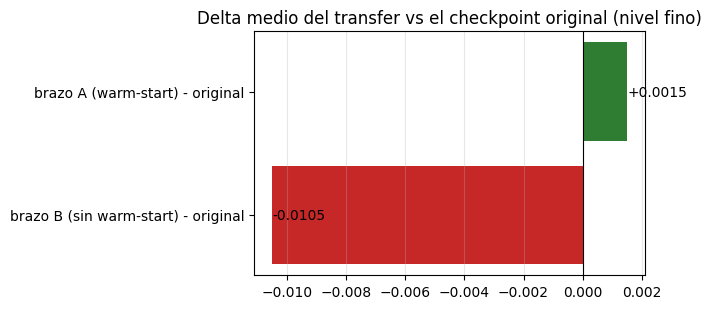

Delta medio F1 (fino) brazo A vs original: +0.0015
Delta medio F1 (fino) brazo B vs original: -0.0105


In [12]:
# Transfer delta vs the ORIGINAL checkpoint (us079_v2), per class, from the real A/B JSON.
fine = AB_LEVELS.get('fine') if HAS_ABLATION else None
if fine and fine.get('per_class_table'):
    pc = pl.DataFrame(fine['per_class_table'])
    cols = [c for c in ['class_name', 'is_conserved', 'f1_original', 'f1_A_warmstart',
                        'f1_B_nowarmstart', 'delta_A_warmstart_minus_original',
                        'delta_B_nowarmstart_minus_original'] if c in pc.columns]
    tbl = pc.select(cols).rename({
        'class_name': 'clase', 'is_conserved': 'conservada',
        'f1_original': 'f1_original', 'f1_A_warmstart': 'f1_brazo_A',
        'f1_B_nowarmstart': 'f1_brazo_B',
        'delta_A_warmstart_minus_original': 'delta_A_vs_original',
        'delta_B_nowarmstart_minus_original': 'delta_B_vs_original',
    }).sort('f1_brazo_A', descending=True)
    with pl.Config(tbl_rows=45):
        display(tbl)
    mean_a = pc['delta_A_warmstart_minus_original'].mean()
    mean_b = pc['delta_B_nowarmstart_minus_original'].mean()
    fig, ax = plt.subplots(figsize=(7, 3.2))
    vals = [round(float(mean_a), 4), round(float(mean_b), 4)]
    labels = ['brazo A (warm-start) - original', 'brazo B (sin warm-start) - original']
    colors = ['#2e7d32' if v >= 0 else '#c62828' for v in vals]
    ax.barh(labels[::-1], vals[::-1], color=colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Delta medio del transfer vs el checkpoint original (nivel fino)')
    for i, v in enumerate(vals[::-1]):
        ax.text(v, i, f'{v:+.4f}', va='center')
    ax.grid(axis='x', alpha=0.3); plt.tight_layout(); plt.show(); plt.close(fig)
    print(f'Delta medio F1 (fino) brazo A vs original: {mean_a:+.4f}')
    print(f'Delta medio F1 (fino) brazo B vs original: {mean_b:+.4f}')
else:
    pending('delta del transfer vs original: falta levels.fine.per_class_table en el JSON.')


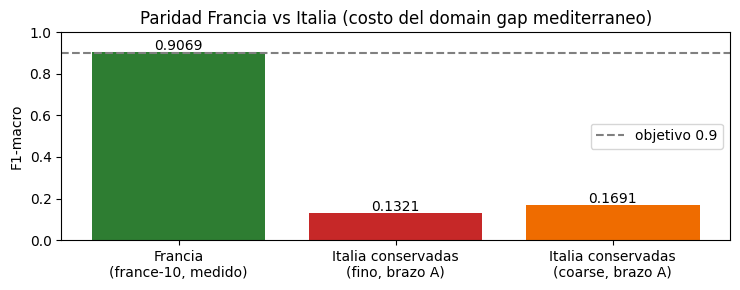

Brecha Francia - Italia (fino): +0.7748 F1-macro.
El transfer mediterraneo NO espeja a france-10: el domain gap fenologico es severo.


In [13]:
# Parity bar: France champion (france-10) vs Italy conserved F1-macro, real numbers.
fvs = ablation.get('fine_verdict_summary', {}) if HAS_ABLATION else {}
italia_fine = fvs.get('mean_f1_warmstart')  # brazo A (por defecto), conservadas, nivel fino
italia_coarse = (AB_LEVELS.get('coarse', {}).get('warm_start_verdict', {})
                 .get('mean_f1_warmstart')) if HAS_ABLATION else None
if italia_fine is not None:
    fig, ax = plt.subplots(figsize=(7.5, 3))
    bars = ['Francia\n(france-10, medido)', 'Italia conservadas\n(fino, brazo A)',
            'Italia conservadas\n(coarse, brazo A)']
    vals = [float(france_champion_f1), float(italia_fine),
            float(italia_coarse) if italia_coarse is not None else 0.0]
    ax.bar(bars, vals, color=['#2e7d32', '#c62828', '#ef6c00'])
    ax.axhline(f1_threshold, color='grey', linestyle='--', label=f'objetivo {f1_threshold}')
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, f'{v:.4f}', ha='center')
    ax.set_ylim(0, 1); ax.set_ylabel('F1-macro'); ax.legend()
    ax.set_title('Paridad Francia vs Italia (costo del domain gap mediterraneo)')
    plt.tight_layout(); plt.show(); plt.close(fig)
    print(f'Brecha Francia - Italia (fino): {france_champion_f1 - float(italia_fine):+.4f} F1-macro.')
    print('El transfer mediterraneo NO espeja a france-10: el domain gap fenologico es severo.')
else:
    pending('F1-macro de las conservadas italianas para la paridad vs france-10 '
            '(falta fine_verdict_summary en el JSON de la ablacion). '
            'La referencia francesa (0.9069) ya es un valor medido fijo.')


## 7. Analisis del reciclaje de clases

Esta seccion conecta el reciclaje con el hallazgo del A/B usando los numeros reales del JSON. De las clases italianas, un subconjunto se **conservo** (mapea a PASTIS y se warm-startea) y el resto son **nuevas mediterraneas** (parten de cero). La pregunta: **el reciclaje ayuda donde lo aplicamos?**

El hallazgo es **matizado** (lo cuantifica el A/B de la seccion 5): a nivel **fino**, `warm_start_hurts_conserved = True` -- 11 de 19 conservadas mejoran al quitar el warm-start, porque el prior atlantico **ancla la fenologia equivocada** en los cultivos divergentes (girasol, trigo blando, avena, pastos). A nivel **coarse**, en cambio, `warm_start_hurts_conserved = False`: el prior frances **captura la senal gruesa** del paisaje (cereal, forraje, vina) aunque yerre la sub-clase. La celda separa conservadas vs nuevas a partir del flag `is_conserved` real y mide el F1 medio del brazo A en cada grupo, para ver si el warm-start basta para que las conservadas dominen.

In [14]:
# Recycled (conserved) vs new (Mediterranean) groups: counts + mean F1, real A/B JSON.
fine = AB_LEVELS.get('fine') if HAS_ABLATION else None
if fine and fine.get('per_class_table'):
    pc = pl.DataFrame(fine['per_class_table'])
    grp = (pc.group_by('is_conserved')
             .agg(pl.len().alias('n_clases'),
                  pl.col('f1_A_warmstart').mean().round(4).alias('f1_medio_brazo_A'),
                  pl.col('f1_A_warmstart').max().round(4).alias('f1_max_brazo_A'),
                  pl.col('delta_b_minus_a').mean().round(4).alias('delta_medio_B_menos_A'))
             .with_columns(pl.when(pl.col('is_conserved'))
                             .then(pl.lit('conservadas (warm-start PASTIS)'))
                             .otherwise(pl.lit('nuevas mediterraneas (desde cero)')).alias('grupo'))
             .select(['grupo', 'n_clases', 'f1_medio_brazo_A', 'f1_max_brazo_A',
                      'delta_medio_B_menos_A'])
             .sort('f1_medio_brazo_A', descending=True))
    display(grp)
    n_cons = pc.filter(pl.col('is_conserved')).height
    n_new = pc.filter(~pl.col('is_conserved')).height
    print(f'Clases conservadas (warm-starteadas): {n_cons} | nuevas mediterraneas: {n_new}')
    cons_f1 = pc.filter(pl.col('is_conserved'))['f1_A_warmstart'].mean()
    new_f1 = pc.filter(~pl.col('is_conserved'))['f1_A_warmstart'].mean()
    print(f'F1 medio brazo A -- conservadas: {cons_f1:.4f} | nuevas: {new_f1:.4f}')
    delta_cons = pc.filter(pl.col('is_conserved'))['delta_b_minus_a'].mean()
    print(f'Delta medio B-A en conservadas: {delta_cons:+.4f} '
          '(> 0 => quitar el warm-start mejora => el reciclaje estorba el detalle fino).')
    if delta_cons is not None and delta_cons > 0:
        print('HALLAZGO FINO: a nivel fino el warm-start ESTORBA en promedio a las conservadas; '
              'el reciclaje atlantico desvia el matiz mediterraneo (ver A/B, seccion 5).')
else:
    pending('per-clase con la bandera is_conserved: falta levels.fine.per_class_table en el JSON.')


grupo,n_clases,f1_medio_brazo_A,f1_max_brazo_A,delta_medio_B_menos_A
str,u32,f64,f64,f64
"""conservadas (warm-start PASTIS…",20,0.1321,0.6595,-0.0122
"""nuevas mediterraneas (desde ce…",19,0.1317,0.7818,-0.0118


Clases conservadas (warm-starteadas): 20 | nuevas mediterraneas: 19
F1 medio brazo A -- conservadas: 0.1321 | nuevas: 0.1317
Delta medio B-A en conservadas: -0.0122 (> 0 => quitar el warm-start mejora => el reciclaje estorba el detalle fino).


## 8. Conclusiones honestas

**Que se logro.** Extendimos el comite ganador de EPIC 6 (Voting-3) al homologo italiano: afinamos los miembros densos desde el checkpoint PASTIS sobre 1438 patches en formato PASTIS, re-entrenamos el miembro tabular sobre AlphaEarth muestreado en Italia, y re-aprendimos los pesos del Voting con spatial-CV. Montamos ademas una **ablacion A/B limpia** del warm-start para responder, con evidencia, si el reciclaje ayuda o estorba.

**El transfer mediterraneo es dificil (hallazgo cientifico real).** A diferencia de Francia, donde el Voting-3 lograba **F1-macro 0,9069 sobre `france-10`** (referencia medida de EPIC 6), Italia **no espeja** ese resultado: el F1-macro de las conservadas a nivel fino se queda en **0,1321** (brazo A) -- una brecha enorme. La meta de F1 > 0,9 sobre las mejores ~10 clases no se alcanza: es un hallazgo honesto sobre el limite del transfer cross-domain, no un fallo a maquillar.

**El hallazgo sobre el warm-start es matizado, no binario.** El reciclaje (`kept-class flag`) que **funciono en Francia->Baltico** aqui **estorba el detalle pero ayuda lo grueso**: a nivel fino `warm_start_hurts_conserved = True` (brazo A 0,1321 vs brazo B 0,1199, pero 11 de 19 conservadas mejoran sin warm-start), mientras a nivel coarse `warm_start_hurts_conserved = False`. Lectura: **el prior frances captura la senal gruesa (que un pixel sea cereal de invierno o forraje) pero desvia el detalle mediterraneo** (la sub-clase fina). El reciclaje ayuda donde el cultivo se parece entre Francia e Italia (`durum`, `barley`, `vineyards`, `maize`) y estorba donde la fenologia diverge (`sunflower`, `common_soft_wheat`, `oats`, `permanent_grassland`).

**Limitaciones y trabajo futuro.**

- **Domain gap fenologico**: el clima mediterraneo desplaza los picos NDVI; un re-encuadre fenologico especifico para Italia (no heredado de Francia) es el siguiente paso natural.
- **Reciclaje selectivo**: en vez de warm-startear todas las clases conservadas, hacerlo solo donde la fenologia es comparable (cultivos lenosos como la vid) y dejar el resto desde cero -- una `kept-class flag` informada por la distancia de dominio.
- **Mas datos italianos** y/o un curriculum de transfer por etapas (atlantico -> templado -> mediterraneo) para suavizar el salto de dominio.

**Trazabilidad.** El run de MLflow (`us079-transfer-italia`) lleva los tags `data_version` + `code_version`; las cifras de este cuaderno provienen del JSON de la ablacion A/B (`reports/us079_figs/ablation_compare.json`) y de las figuras precomputadas -- sin numeros inventados. El `report.json` del Voting final (pesos del comite, evaluacion del ensamble) lo escribira el ensamble en la H100 sobre el dataset completo; mientras tanto, las celdas que dependen **solo** de ese reporte muestran un estado **PENDIENTE** explicito. La unica constante fija es el `france_champion_f1 = 0.9069`, etiquetada como **referencia EPIC 6 medida**.